<a href="https://colab.research.google.com/github/tasosquantumcomputing/Machine-Learning/blob/main/MultipleLinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We want to make a model in form of mpg = b0 + b1(weight) + b2(displacement)
+b3(cylinders)+.....
---



importing the libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

importing the dataset

In [44]:
df = pd.read_csv('auto-mpg.csv')

Missing Values


In [45]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [46]:
(df == "?").sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model year,0
origin,0
car name,0


So, we have 6 values ? in horsepower data. We will remove this data



In [47]:
df['horsepower'] = df['horsepower'].replace('?', np.nan)
df['horsepower'] = df['horsepower'].astype(float)

# Αφαίρεση missing
df = df.dropna()

Feature selection. We dont use origin because is categorical varialbe. (We can do that but we must ise one hot encoding)


In [48]:
features = ['cylinders', 'displacement', 'horsepower',
            'weight', 'acceleration', 'model year']

X = df[features]
y = df['mpg']

Standardization

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train Test Split

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Model Training

In [51]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Model coefficients

In [52]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -15.057758585282361
Coefficients: [-0.116173    0.00101347 -0.00227634 -0.00656101  0.06173551  0.76063644]


Predictions

In [53]:
y_pred = model.predict(X_test)

Model Evaluation

In [54]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 10.502370329417325
R2: 0.7942349075428586


Multicollinearity Check

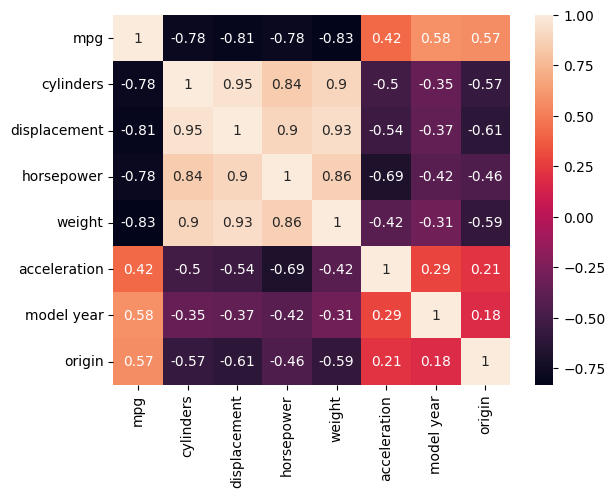

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

Residual Plot

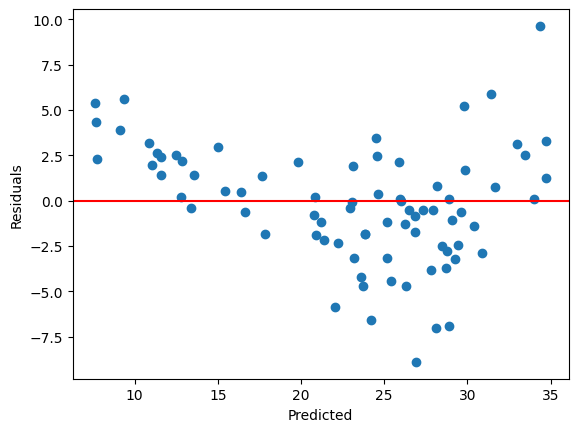

In [56]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

Predictions for a  new car

In [57]:
new_car = pd.DataFrame({
    'cylinders': [4],
    'displacement': [120],
    'horsepower': [95],
    'weight': [2300],
    'acceleration': [15.0],
    'model year': [82]
})

prediction = model.predict(new_car)

print("Predicted MPG:", prediction[0])

Predicted MPG: 32.59082087607909


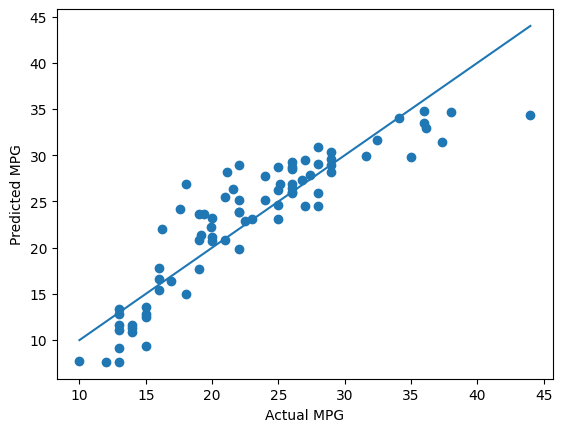

In [58]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.show()

Function for predictions

In [59]:
def predict_mpg(cyl, disp, hp, weight, acc, year):
    new_data = pd.DataFrame({
        'cylinders': [cyl],
        'displacement': [disp],
        'horsepower': [hp],
        'weight': [weight],
        'acceleration': [acc],
        'model year': [year]
    })

    return model.predict(new_data)[0]

In [60]:
predict_mpg(4, 120, 95, 2300, 15, 82)

np.float64(32.59082087607909)